# Analiza opisowa

Celem etapu jest przedstawienie charakterystyki zbioru danych po procesie czyszczenia i imputacji braków. Analiza opisowa stanowi fundament dalszych etapów pracy, ponieważ pozwala zrozumieć strukturę danych, ich rozkłady, zależności oraz potencjalne ograniczenia.

W pierwszym kroku sprawdzamy podstawowe informacje o zbiorze danych po procesie czyszczenia i imputacji. Weryfikujemy liczbę obserwacji i zmiennych, typy danych oraz ogólną strukturę zbioru. Pozwala to zweryfikować poprawność przygotowania danych oraz określić, które zmienne będą analizowane w kolejnych etapach.

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimpy import skim
from scipy import stats
from tabulate import tabulate

sales_clean = pd.read_csv("../Dane/Czyste/sales_clean.csv")

W pierwszym kroku analizujemy strukturę zbioru danych po czyszczeniu, aby upewnić się, że dane są kompletne i gotowe do dalszej eksploracji.

In [33]:
info_df = pd.DataFrame({
    "dtype": sales_clean.dtypes,
    "non_null": sales_clean.notna().sum(),
    "null": sales_clean.isna().sum(),
})

info_df["missing_percent"] = (info_df["null"] / len(sales_clean) * 100).round(2)

info_df.style.format({"missing_percent": "{:.2f}%"}).background_gradient(cmap="Purples")

,dtype,non_null,null,missing_percent
id,str,195568,0,0.00%
city,str,195568,0,0.00%
type,str,195568,0,0.00%
squareMeters,float64,195568,0,0.00%
rooms,float64,195568,0,0.00%
floor,float64,195568,0,0.00%
floorCount,float64,195568,0,0.00%
buildYear,float64,195568,0,0.00%
latitude,float64,195568,0,0.00%
longitude,float64,195568,0,0.00%


Zbiór danych po procesie czyszczenia i imputacji obejmuje **195 568 obserwacji** oraz **28 zmiennych** opisujących cechy mieszkań, ich lokalizację, wyposażenie oraz ceny ofertowe. Wszystkie zmienne są kompletne — liczba braków wynosi 0, co potwierdza poprawność przeprowadzonego etapu przygotowania danych.

W strukturze danych wyróżnia się:
- **16 zmiennych numerycznych** (m.in. powierzchnia, liczba pokoi, piętro, rok budowy, współrzędne geograficzne, odległości do punktów usługowych),
- **11 zmiennych kategorycznych** opisujących typ nieruchomości, miasto, formę własności oraz elementy wyposażenia,
- **1 zmienna całkowitoliczbowa** reprezentująca cenę (*price*).

Przegląd pierwszych obserwacji wskazuje, że dane są spójne, a wartości zmiennych odpowiadają oczekiwanym zakresom. Zmienna `id` pełni funkcję identyfikatora, natomiast `month` pozwala na analizę zmian w czasie. Zmienna `type` obejmuje m.in. kategorie *blockOfFlats* oraz *tenement*, co umożliwia dalsze porównania między typami zabudowy.

Powyższe zestawienia pozwalają ocenić, czy dane zostały poprawnie wczytane oraz czy struktura zbioru odpowiada oczekiwaniom po etapie czyszczenia. Aby lepiej zrozumieć charakterystykę zmiennych numerycznych, obliczamy podstawowe statystyki opisowe, takie jak średnia, mediana, odchylenie standardowe oraz zakres wartości.

## Statystyki opisowe zmiennych numerycznych

In [40]:
(
    sales_clean.describe()
    .T
    .style
    .format("{:.2f}")
    .background_gradient(cmap="Greens")
    .set_caption("Statystyki opisowe zmiennych numerycznych")
)


,count,mean,std,min,25%,50%,75%,max
squareMeters,195568.00,58.70,21.41,25.00,44.00,54.60,68.55,150.00
rooms,195568.00,2.68,0.92,1.00,2.00,3.00,3.00,6.00
floor,195568.00,3.30,2.48,0.00,2.00,3.00,4.00,29.00
floorCount,195568.00,5.29,3.29,1.00,3.00,4.00,6.00,29.00
buildYear,195568.00,1985.30,32.59,1850.00,1969.00,1991.00,2013.00,2024.00
latitude,195568.00,52.03,1.34,49.98,51.11,52.19,52.41,54.61
longitude,195568.00,19.47,1.78,14.45,18.52,19.90,20.99,23.21
centreDistance,195568.00,4.35,2.84,0.01,2.01,3.98,6.15,16.94
poiCount,195568.00,20.67,24.33,0.00,7.00,14.00,24.00,212.00
schoolDistance,195568.00,0.41,0.46,0.00,0.18,0.29,0.47,4.95


Inną biblioteką pozwalającą w prosty sposób dokonać analizy rozkładu zmiennych jest bibliteka skim. Dokonuje ona także weryfikacji zmiennych kategorycznych.

In [22]:
skim(sales_clean)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 195568 │ │ float64     │ 16    │                                                          │
│ │ Number of columns │ 28     │ │ string      │ 11    │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                ┃ NA ┃ NA % ┃ mean   ┃ sd     ┃ p0     ┃ p25    ┃ p50    ┃ p75    ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │     squareMeters      │  0 │    0 │   58.7 │  21.41 │     25 │     44 │   54.6 │  68.55 │     150 │  ▅▇▃▁  │  │
│ │         rooms         │  0 │    0 │  2.679 │  0.915 │      1 │      2 │      3 │      3 │       6 │ ▁▇▇▂▁  │  │
│ │         floor         │  0 │    0 │  3.297 │  2.483 │      0 │      2 │      3 │      4 │      29 │   ▇▂   │  │
│ │      floorCount       │  0 │    0 │  5.295 │  3.295 │      1 │      3 │      4 │      6 │      29 │  ▇▃▁   │  │
│ │       buildYear       │  0 │    0 │   1985 │  32.59 │   1850 │   1969 │   1991 │   2013 │    2024 │   ▂▂▆▇ │  │
│ │       latitude        │  0 │    0 │  52.03 │  1.335 │  49.98 │  51.11 │  52.19 │  52.41 │   54.61 │ ▅▃▇▂▂▃ │  │
│ │       longitude       │  0 │    0 │  19.47 │  1.783 │  14.45 │  18.52 │   19.9 │  20.99 │   23.21 │ ▁▃▅▇▇▁ │  │
│ │    centreDistance     │  0 │    0 │  4.351 │  2.836 │   0.01 │   2.01 │   3.98 │   6.15 │   16.94 │  ▇▇▅▂  │  │
│ │       poiCount        │  0 │    0 │  20.67 │  24.33 │      0 │      7 │     14 │     24 │     212 │   ▇▁   │  │
│ │    schoolDistance     │  0 │    0 │ 0.4125 │  0.464 │  0.002 │  0.176 │   0.29 │  0.467 │   4.946 │   ▇▁   │  │
│ │    clinicDistance     │  0 │    0 │ 0.9692 │ 0.8874 │  0.001 │  0.357 │  0.676 │  1.236 │   4.999 │  ▇▃▁▁  │  │
│ │  postOfficeDistance   │  0 │    0 │ 0.5162 │ 0.4977 │  0.001 │  0.239 │  0.393 │  0.623 │    4.97 │   ▇▁   │  │
│ │ kindergartenDistance  │  0 │    0 │ 0.3674 │ 0.4445 │  0.001 │  0.156 │  0.262 │  0.416 │   4.961 │   ▇    │  │
│ │  restaurantDistance   │  0 │    0 │  0.345 │  0.463 │  0.001 │  0.114 │  0.229 │  0.408 │   4.985 │   ▇    │  │
│ │    collegeDistance    │  0 │    0 │  1.434 │   1.09 │  0.004 │  0.588 │   1.12 │  2.028 │       5 │ ▇▆▃▂▁▁ │  │
│ │   pharmacyDistance    │  0 │    0 │ 0.3579 │ 0.4574 │  0.001 │  0.142 │  0.239 │  0.406 │   4.992 │   ▇    │  │
│ │         price         │  0 │    0 │ 784200 │ 409700 │ 150000 │ 520000 │ 699000 │ 930000 │ 3250000 │  ▇▇▂   │  │
│ └───────────────────────┴────┴──────┴────────┴────────┴────────┴────────┴────────┴────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min 

Zbiór danych zawiera 17 zmiennych numerycznych opisujących cechy mieszkań, ich lokalizację oraz odległości od punktów usługowych. Wszystkie zmienne są kompletne, a ich rozkłady są zróżnicowane pod względem zakresu i wariancji.

Powierzchnia mieszkań (`squareMeters`) ma medianę 54,6 m² i średnią 58,7 m², co wskazuje na lekką skośność w prawo wynikającą z obecności większych lokali (maksymalnie 150 m²). Liczba pokoi (`rooms`) jest zmienną dyskretną, z dominacją mieszkań 2‑ i 3‑pokojowych.

Zmienne związane z kondygnacją budynku (`floor`, `floorCount`) mają mediany odpowiednio 3 i 4, przy czym maksymalne wartości sięgają 29 pięter, co odzwierciedla obecność zarówno niskiej, jak i wysokiej zabudowy.

Rok budowy ('buildYear') charakteryzuje się szerokim zakresem — od 1850 do 2024 roku — z medianą 1991. Rozkład jest wyraźnie skośny, co wynika z dużej liczby nowszych inwestycji.

Zmienne przestrzenne (`latitude`, `longitude`) wykazują niewielką wariancję, co potwierdza, że dane dotyczą ograniczonego obszaru geograficznego.

Odległości do punktów usługowych (np. `schoolDistance`, `clinicDistance`, `restaurantDistance`) mają rozkłady silnie skośne w prawo — większość mieszkań znajduje się blisko usług, natomiast pojedyncze obserwacje reprezentują lokalizacje peryferyjne.

Cena ofertowa (`price`) ma medianę 699 000 zł i średnią 784 200 zł, co wskazuje na obecność mieszkań o bardzo wysokich cenach (maksymalnie 3,25 mln zł). Rozkład jest wyraźnie skośny, co jest typowe dla danych rynkowych.


## Statystyki opisowe zmiennych kategorycznych

Po analizie zmiennych numerycznych przechodzimy do zmiennych kategorycznych, które opisują lokalizację, typ nieruchomości oraz elementy wyposażenia mieszkań.

In [41]:
(
    sales_clean.describe(include="object")
    .T
    .style
    .background_gradient(cmap="Purples")
    .set_caption("Statystyki opisowe zmiennych kategorycznych")
)

C:\Users\Użytkownik\AppData\Local\Temp\ipykernel_22356\2041164242.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  sales_clean.describe(include="object")


,count,unique,top,freq
id,195568,92967,d59165364f1c4b3d658890e808e7d77c,11
city,195568,15,warszawa,59246
type,195568,3,blockOfFlats,133629
ownership,195568,3,condominium,176123
buildingMaterial,195568,3,brick,115092
hasParkingSpace,195568,2,no,142410
hasBalcony,195568,2,yes,112049
hasElevator,195568,2,no,103137
hasSecurity,195568,2,no,173630
hasStorageRoom,195568,2,no,110583


Statystyki zmiennych kategorycznych pozwalają ocenić dominujące wartości oraz strukturę rynku mieszkaniowego w badanym zbiorze.

Zbiór danych zawiera 11 zmiennych kategorycznych opisujących lokalizację, typ nieruchomości, formę własności oraz elementy wyposażenia. Wszystkie zmienne są kompletne, a ich liczność pozwala na dalszą analizę zależności.

Najliczniejszym miastem w zbiorze jest **Warszawa** (ok. 59 tys. obserwacji), co odzwierciedla dominację ofert z największego rynku mieszkaniowego. Wśród typów zabudowy przeważają **mieszkania w blokach** (`blockOfFlats`), które stanowią ponad 68% wszystkich obserwacji. Najczęściej występującą formą własności jest `condominium` (ponad 176 tys. ofert), czyli mieszkanie z prawem własności.

W zmiennych dotyczących wyposażenia dominują wartości binarne „yes/no”. Najczęściej brak jest: windy, ochrony oraz komórki lokatorskiej, co sugeruje przewagę starszego budownictwa lub niskiej zabudowy. Z kolei balkon występuje częściej niż jego brak.

Zmienna `month` obejmuje 11 miesięcy od **2023_08 do 2024_06**, co pozwala na analizę zmian cen i podaży w czasie.


## Analiza zależności między zmiennymi numerycznymi

Kolejnym krokiem jest analiza zależności między zmiennymi numerycznymi. Pozwala to zidentyfikować cechy, które mogą mieć największy wpływ na cenę mieszkań.

In [46]:
corr_matrix = sales_clean.corr(numeric_only=True)

from tabulate import tabulate
print(tabulate(corr_matrix.round(3), headers='keys', tablefmt='github'))

|                      |   squareMeters |   rooms |   floor |   floorCount |   buildYear |   latitude |   longitude |   centreDistance |   poiCount |   schoolDistance |   clinicDistance |   postOfficeDistance |   kindergartenDistance |   restaurantDistance |   collegeDistance |   pharmacyDistance |   price |
|----------------------|----------------|---------|---------|--------------|-------------|------------|-------------|------------------|------------|------------------|------------------|----------------------|------------------------|----------------------|-------------------|--------------------|---------|
| squareMeters         |          1     |   0.827 |  -0.084 |       -0.133 |      -0.026 |      0.044 |      -0.026 |            0.044 |      0.039 |            0.069 |            0.015 |                0.058 |                  0.074 |                0.035 |             0.032 |              0.061 |   0.638 |
| rooms                |          0.827 |   1     |  -0.041 |       -0

Aby lepiej zobrazować zależności między zmiennymi, przedstawiamy macierz korelacji w formie graficznej.

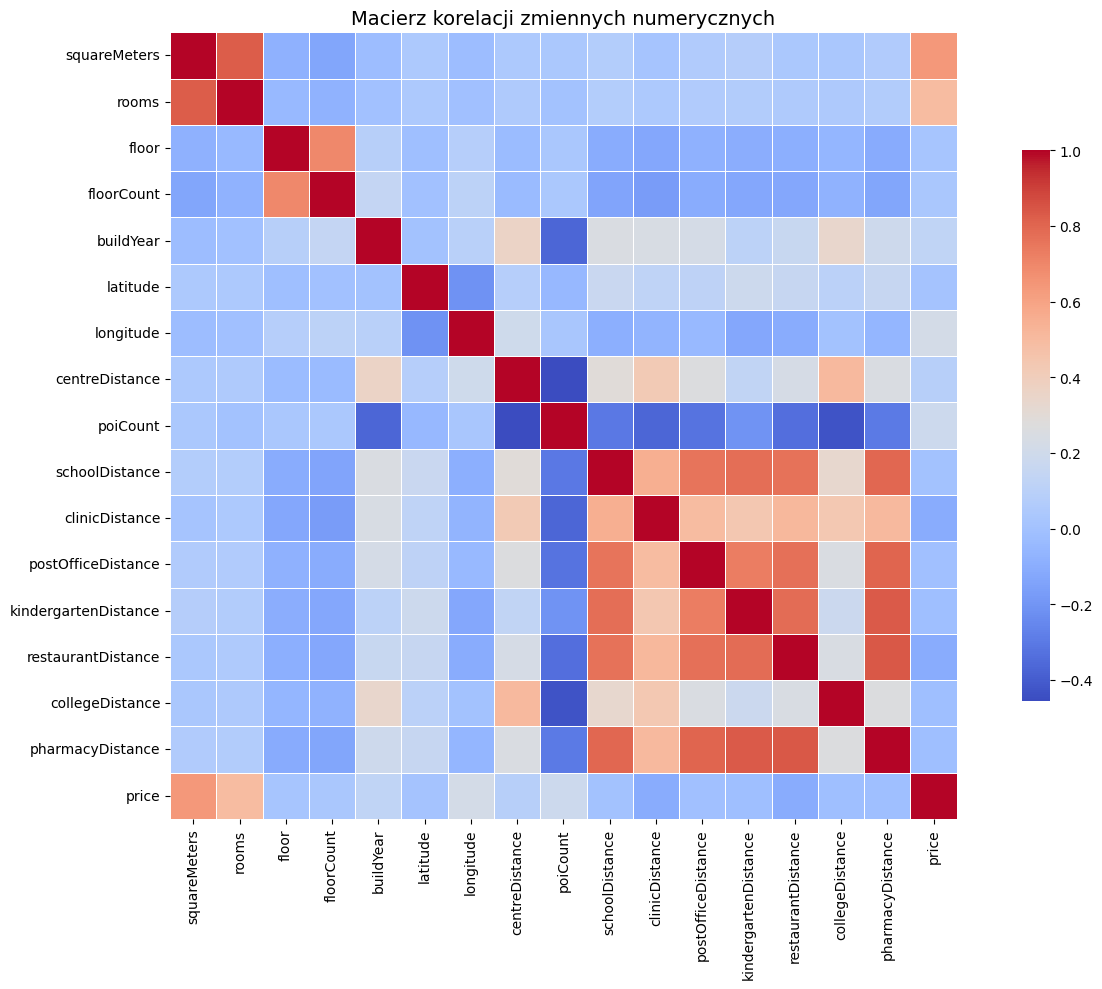

In [44]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.7}
)
plt.title("Macierz korelacji zmiennych numerycznych", fontsize=14)
plt.tight_layout()
plt.show()

Następnie analizujemy, które zmienne wykazują najsilniejszą korelację z ceną ofertową mieszkań.

In [48]:
price_corr_df = price_corr.head(10).to_frame("correlation")

(
    price_corr_df.style
    .format("{:.3f}")
    .background_gradient(cmap="coolwarm")
    .set_caption("Najsilniejsze korelacje z ceną")
)

,correlation
price,1.000
squareMeters,0.638
rooms,0.495
longitude,0.219
poiCount,0.185
buildYear,0.130
centreDistance,0.090
floorCount,0.032
floor,0.017
latitude,0.011


 Najwyższą dodatnią korelację z ceną wykazuje **powierzchnia (0,64)** oraz **liczba pokoi (0,50)**, co potwierdza, że podstawowym czynnikiem determinującym wartość nieruchomości jest jej metraż. Umiarkowaną dodatnią korelację obserwuje się również dla współrzędnej geograficznej `longitude` (0,22), co odzwierciedla różnice cen między miastami położonymi bardziej na wschód i zachód kraju.

Zmienna `buildYear` wykazuje słabą, lecz dodatnią korelację z ceną (0,13), co sugeruje, że nowsze budynki są przeciętnie droższe, choć zależność ta nie jest silna. Zmienna `centreDistance` ma niewielką dodatnią korelację (0,09), co może wynikać z różnic między miastami — w części lokalizacji mieszkania poza ścisłym centrum są droższe (np. nowe osiedla).

Zmiennie odległościowe mają bardzo słabe lub ujemne korelacje z ceną, co wskazuje, że ich wpływ na wartość nieruchomości jest niewielki lub nieliniowy. Silne dodatnie korelacje między samymi zmiennymi odległościowymi (np. `schoolDistance` i `pharmacyDistance`, 0,80) wynikają z ich wspólnej natury przestrzennej — lokalizacje peryferyjne są jednocześnie oddalone od wielu usług.

Podsumowując, cena mieszkań jest przede wszystkim związana z ich powierzchnią i liczbą pokoi, natomiast pozostałe zmienne numeryczne mają znaczenie drugorzędne lub pośrednie.


## Analiza zależności cen mieszkań między miastami

Po ogólnej analizie zależności przechodzimy do porównania cen mieszkań w podziale na miasta, aby ocenić zróżnicowanie regionalne rynku.

In [49]:
city_price = sales_clean.groupby("city")["price"].describe()

(
    city_price
    .round(2)  # usuwa notację wykładniczą
    .style
    .format({
        "count": "{:.0f}",   # count jako liczba całkowita
        "mean": "{:,.0f}",   # mean bez notacji wykładniczej
        "std": "{:,.0f}",
        "min": "{:,.0f}",
        "25%": "{:,.0f}",
        "50%": "{:,.0f}",
        "75%": "{:,.0f}",
        "max": "{:,.0f}",
    })
    .background_gradient(cmap="Blues")
    .set_caption("Statystyki cen mieszkań w podziale na miasta")
)


,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
bialystok,2464,"476,853","120,168","265,000","380,000","450,000","550,000","905,000"
bydgoszcz,9547,"422,066","164,329","150,000","299,000","379,900","527,000","1,000,000"
czestochowa,2657,"350,449","124,717","165,000","265,000","320,000","399,000","835,000"
gdansk,19210,"838,555","341,907","300,000","599,000","749,000","990,000","2,499,000"
gdynia,8164,"819,680","423,973","300,000","549,000","696,000","950,000","3,059,665"
katowice,5284,"502,571","207,657","151,200","350,000","459,709","619,225","1,390,000"
krakow,29026,"897,889","394,186","255,000","649,000","795,000","1,049,000","3,000,000"
lodz,15300,"436,539","164,617","169,000","315,000","395,000","525,000","1,050,000"
lublin,5704,"555,014","158,440","200,000","440,000","530,000","644,000","1,200,000"


Analiza cen ofertowych w podziale na miasta ujawnia bardzo wyraźne różnice między lokalnymi rynkami mieszkaniowymi. Najwyższe średnie ceny występują w dużych ośrodkach metropolitalnych: Warszawie (1,02 mln zł), Krakowie (0,90 mln zł), Gdańsku (0,84 mln zł) i Gdyni (0,82 mln zł). Rynki te charakteryzują się również największą zmiennością cen, co odzwierciedla szeroki przekrój dostępnych nieruchomości — od mieszkań w starszej zabudowie po nowe inwestycje premium.

W miastach średniej wielkości, takich jak Poznań, Wrocław, Lublin czy Szczecin, średnie ceny oscylują w przedziale 0,55–0,75 mln zł. Rynki te są bardziej jednorodne, a rozkład cen wskazuje na mniejszy udział nieruchomości luksusowych.

Najniższe ceny obserwuje się w miastach takich jak Częstochowa, Radom, Białystok czy Bydgoszcz, gdzie mediany cen wynoszą 0,32–0,45 mln zł. Rynki te charakteryzują się również mniejszą zmiennością, co sugeruje bardziej spójny profil ofert.

Podsumowując, ceny mieszkań w Polsce wykazują silne zróżnicowanie regionalne, a ich poziom jest ściśle powiązany z wielkością miasta, atrakcyjnością rynku pracy oraz dostępnością nowego budownictwa.



## Testy różnic między miastami (ANOVA i Kruskal‑Wallis)

Aby statystycznie potwierdzić zaobserwowane różnice cen między miastami, przeprowadzamy testy porównujące rozkłady cen w wielu grupach.

In [26]:
# Przygotowanie danych
groups = [group["price"].values for name, group in sales_clean.groupby("city")]

# Test ANOVA
anova_stat, anova_p = stats.f_oneway(*groups)

# Test Kruskal-Wallis
kw_stat, kw_p = stats.kruskal(*groups)

# Wyniki w czytelnej tabeli
results = [
    ["ANOVA", anova_stat, anova_p],
    ["Kruskal-Wallis", kw_stat, kw_p]
]

print(tabulate(results, headers=["Test", "Statystyka", "p-value"], tablefmt="github"))


| Test           |   Statystyka |   p-value |
|----------------|--------------|-----------|
| ANOVA          |      5740.38 |         0 |
| Kruskal-Wallis |     83497.1  |         0 |


W celu weryfikacji, czy ceny mieszkań różnią się istotnie między grupami przeprowadzono dwa testy: ANOVA oraz Kruskal‑Wallis. Oba testy zwróciły wartości p równe 0, co oznacza istotność statystyczną.

**Wynik ANOVA (F = 5740.38, p = 0)** wskazuje, że średnie ceny mieszkań różnią się istotnie między analizowanymi grupami. Test ten zakłada normalność i homogeniczność wariancji, które w przypadku cen nie są w pełni spełnione, dlatego wykonano również test nieparametryczny.

**Wynik testu Kruskal‑Wallisa (H = 83 497.1, p = 0)** potwierdza, że rozkłady cen różnią się istotnie między grupami, niezależnie od założeń dotyczących normalności. Jest to szczególnie ważne, ponieważ ceny mieszkań są zmienną silnie skośną.

Wyniki obu testów są zgodne z wcześniejszą analizą opisową:
- w podziale na miasta obserwowano duże różnice średnich cen (np. Warszawa ~1,02 mln zł vs. Radom ~0,36 mln zł),
- w podziale na typ zabudowy również występowały wyraźne różnice median i rozkładów cen.

Oznacza to, że **lokalizacja oraz typ nieruchomości mają istotny wpływ na poziom cen**, a zróżnicowanie to jest potwierdzone statystycznie zarówno testem parametrycznym, jak i nieparametrycznym.
Oprócz analizy statycznej interesujące jest również zbadanie dynamiki rynku — w szczególności tego, jak często ogłoszenia pojawiają się ponownie w kolejnych miesiącach.


## Ogłoszenia powtarzające się w czasie (Anty-flipping Index)

Interesującym zjawiskiem jest fakt, że część ogłoszeń pojawia się w zbiorze danych wielokrotnie — w różnych miesiącach. Oznacza to, że danego mieszkania nie udało się sprzedać w pierwszym miesiącu, i ogłoszenie zostało wznowione. Ta analiza pozwoli zidentyfikować mieszkania "trudne do sprzedaży" oraz sprawdzić, czy i jak sprzedawcy zmieniali ceny w kolejnych próbach.


In [ ]:
stats_df = pd.DataFrame({
    "Wartość": [
        f"{total_ads:,}",
        f"{len(single_ads):,} ({len(single_ads)/total_ads*100:.1f}%)",
        f"{len(multiple_ads):,} ({len(multiple_ads)/total_ads*100:.1f}%)",
        ad_appearances['appearances'].max()
    ]
}, index=[
    "Liczba unikalnych ogłoszeń",
    "Ogłoszenia pojawiające się raz",
    "Ogłoszenia pojawiające się wielokrotnie",
    "Maksymalna liczba powtórzeń"
])

stats_df.style.set_caption("Statystyka ogłoszeń").background_gradient(cmap="Blues")


,Wartość
Liczba unikalnych ogłoszeń,"92,967"
Ogłoszenia pojawiające się raz,"47,620 (51.2%)"
Ogłoszenia pojawiające się wielokrotnie,"45,347 (48.8%)"
Maksymalna liczba powtórzeń,11


Statystyka ogłoszeń pokazuje, że rynek mieszkaniowy charakteryzuje się dużą rotacją ofert. W zbiorze znajduje się 92 967 unikalnych ogłoszeń, z czego 51,2% pojawia się tylko raz, natomiast aż 48,8% powtarza się w kolejnych miesiącach. Oznacza to, że niemal połowa mieszkań nie sprzedaje się od razu i wymaga ponownego wystawienia. Maksymalna liczba powtórzeń wynosi 11, co wskazuje na obecność ofert wyjątkowo trudnych do sprzedaży.

In [59]:
repeat_dist = (
    multiple_ads['appearances']
    .value_counts()
    .sort_index()
    .to_frame("Liczba ogłoszeń")
)

repeat_dist.style.set_caption("Rozkład liczby powtórzeń ogłoszeń").background_gradient(cmap="Purples")

,Liczba ogłoszeń
appearances,
2,21369
3,10708
4,5709
5,2764
6,1650
7,1263
8,615
9,429
10,332


Rozkład liczby powtórzeń wskazuje, że najczęściej ogłoszenia pojawiają się 2 lub 3 razy (odpowiednio 21 369 i 10 708 przypadków). Kolejne poziomy powtórzeń występują coraz rzadziej, co sugeruje naturalny cykl rynkowy: jeśli mieszkanie nie sprzeda się w pierwszym miesiącu, sprzedawca zwykle ponawia ofertę 1–2 razy. Jednocześnie 508 ogłoszeń pojawia się aż 11 razy, co wskazuje na mieszkania wyjątkowo trudne do sprzedaży — prawdopodobnie z powodu ceny, lokalizacji lub stanu technicznego.
Ponieważ część ogłoszeń pojawia się wielokrotnie, sprawdzamy teraz, czy sprzedawcy modyfikują ceny w kolejnych miesiącach i jak duże są te zmiany.

In [60]:
price_change_df = pd.DataFrame({
    "Wartość": [
        f"{len(ads_with_price_change):,} ({len(ads_with_price_change)/len(multiple_ads)*100:.1f}%)",
        f"{avg_price_change.mean():.2f}%",
        f"{avg_price_change.median():.2f}%",
        f"{avg_price_change.min():.2f}% / {avg_price_change.max():.2f}%"
    ]
}, index=[
    "Ogłoszenia ze zmianą ceny",
    "Średnia zmiana ceny",
    "Mediana zmiany ceny",
    "Min / Max zmiana ceny"
])

price_change_df.style.set_caption("Statystyki zmian cen").background_gradient(cmap="Greens")

,Wartość
Ogłoszenia ze zmianą ceny,"12,937 (28.5%)"
Średnia zmiana ceny,6.02%
Mediana zmiany ceny,4.29%
Min / Max zmiana ceny,0.00% / 131.22%


Zmiany cen dotyczą 28,5% ogłoszeń powtarzających się, co oznacza, że sprzedawcy często reagują na brak zainteresowania obniżką ceny. Średnia zmiana wynosi 6,02%, a mediana 4,29%, co sugeruje umiarkowane korekty cenowe. Największa odnotowana zmiana to aż 131,22%, co wskazuje na pojedyncze przypadki bardzo dużych korekt — prawdopodobnie wynikających z błędów w pierwotnej wycenie lub radykalnej zmiany strategii sprzedaży. Aby lepiej zrozumieć, które mieszkania są najtrudniejsze do sprzedaży, analizujemy teraz ogłoszenia o największej liczbie powtórzeń.

In [61]:
top_persistent_df = (
    multiple_ads.nlargest(10, 'appearances')
    [["city", "sqm", "rooms", "appearances", "price_mean", "type"]]
    .rename(columns={
        "city": "Miasto",
        "sqm": "Powierzchnia",
        "rooms": "Pokoje",
        "appearances": "Powtórzenia",
        "price_mean": "Średnia cena",
        "type": "Typ"
    })
)

(
    top_persistent_df
    .style
    .format({
        "Powierzchnia": "{:.0f}",
        "Pokoje": "{:.0f}",
        "Powtórzenia": "{:.0f}",
        "Średnia cena": "{:,.0f}"
    })
    .background_gradient(cmap="OrRd")
    .set_caption("TOP 10 najtrwalszych ogłoszeń")
)


,Miasto,Powierzchnia,Pokoje,Powtórzenia,Średnia cena,Typ
531,bialystok,64,3,11,"599,909",blockOfFlats
614,warszawa,63,3,11,"1,209,364",blockOfFlats
653,szczecin,71,3,11,"427,000",tenement
840,krakow,47,2,11,"681,273",tenement
1544,gdynia,60,2,11,"650,000",blockOfFlats
1619,krakow,68,3,11,"1,116,370",apartmentBuilding
1981,warszawa,70,3,11,"1,177,273",blockOfFlats
2128,szczecin,125,5,11,"799,000",tenement
2149,poznan,48,2,11,"577,636",tenement
2505,poznan,91,4,11,"734,182",blockOfFlats


Najtrwalsze ogłoszenia — pojawiające się aż 11 razy — dotyczą mieszkań z różnych miast i typów zabudowy. Wśród nich znajdują się zarówno mieszkania w blokach, jak i w kamienicach oraz budynkach apartamentowych. Powierzchnie wahają się od 47 do 125 m², a średnie ceny od 427 tys. zł do ponad 1,2 mln zł. Oznacza to, że problem „utkniętych” ogłoszeń nie dotyczy wyłącznie jednego segmentu rynku — zarówno tańsze, jak i droższe mieszkania mogą mieć trudności ze sprzedażą. Wskazuje to na znaczenie czynników takich jak lokalizacja mikro, standard wykończenia czy konkurencyjność ceny. Podsumowując, analiza ogłoszeń powtarzających się ujawnia istotne zjawisko na rynku mieszkaniowym: duża część ofert wymaga ponownego wystawienia, a sprzedawcy często modyfikują ceny, aby zwiększyć szanse sprzedaży. Informacje te mogą być wykorzystane w dalszych etapach pracy, np. przy budowie modeli przewidujących trudność sprzedaży lub optymalną strategię cenową.

### Wnioski z analizy ogłoszeń powtarzających się

- **Połowa rynku to ogłoszenia "utknięte"**: 48,8% ogłoszeń pojawia się wielokrotnie, co oznacza, że sprzedawcy muszą ponownie wystawiać mieszkania. To wskaźnik trudności rynku — mieszkania trudniej się sprzedają przy pierwszej próbie.
- **Zdecydowana większość czeka 2-3 miesiące**: rozkład pokazuje, że najczęściej ogłoszenia powtarzają się 2-3 razy. To sugeruje naturalny cykl rynkowy — jeśli mieszkanie się nie sprzeda, sprzedawca stara się znowu w następnym miesiącu.
- **Niektóre mieszkania są "widmami"**: 11 ogłoszeń pojawia się aż 11 razy. To prawdopodobnie mieszkania bardzo trudne do sprzedaży — być może cena jest za wysoka, albo położenie neatrakcyjne.
- **Sprzedawcy próbują negocjować**: 28,5% ogłoszeń zmienia cenę między powtórzeniami, średnio o 6% w dół. To sugeruje, że sprzedawcy uczą się z rynku i obniżają cenę, jeśli mieszkanie się nie sprzedaje.
- **Implikacja dla modelowania**: zmienną `appearances` (ile razy ogłoszenie powtórzyło się) możemy użyć jako wskaźnik trudności sprzedaży — mieszkania trudne do sprzedaży mogą mieć inne cechy niż te, które sprzedają się szybko.


## Podsumowanie

Analiza opisowa pozwoliła scharakteryzować zbiór danych obejmujący ponad 195 tys. ofert mieszkaniowych.

Statystyki zmiennych numerycznych wykazały, że mieszkania w zbiorze mają zróżnicowaną powierzchnię, liczbę pokoi oraz rok budowy, co odzwierciedla szeroki przekrój rynku. Zmiennie odległościowe charakteryzują się silną skośnością, co sugeruje, że wpływ lokalizacji na cenę może być nieliniowy.

Macierz korelacji potwierdziła, że cena mieszkań jest przede wszystkim związana z ich powierzchnią i liczbą pokoi, natomiast pozostałe zmienne numeryczne mają znaczenie drugorzędne. Zależności przestrzenne i odległościowe wykazują niskie korelacje z ceną, co wskazuje na konieczność uwzględnienia zmiennych kategorycznych, takich jak miasto czy typ zabudowy.

Analiza cen w podziale na miasta ujawniła silne zróżnicowanie regionalne — najwyższe ceny występują w dużych ośrodkach metropolitalnych, natomiast najniższe w miastach średnich i mniejszych. Różnice te zostały jednoznacznie potwierdzone testami ANOVA i Kruskal‑Wallisa, które wykazały istotne statystycznie różnice między grupami.

Podsumowując, analiza opisowa wskazuje, że rynek mieszkaniowy w Polsce jest silnie zróżnicowany pod względem lokalizacji, typu zabudowy oraz cech fizycznych nieruchomości. Wyniki te stanowią solidną podstawę do dalszych etapów pracy, w szczególności modelowania cen i identyfikacji kluczowych determinant wartości mieszkań.
